In [23]:
import numpy as np
import pandas as pd
from scipy.io import mmread

## P2 (a)

In [24]:
# Load the matrix
# bcspwr09     (Power Networks)

A = mmread("/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/HW2/power-bcspwr09/power-bcspwr09.mtx").tocoo()

# Save as edge list
with open("edges.csv", "w") as f:
    f.write("Source,Target\n")
    for i, j in zip(A.row, A.col):
        if i != j:  # optional: skip self-loops
            f.write(f"{i},{j}\n")

Modularity: 0.893

Modularity with resolution: 0.893

Number of Communities: 24

In [4]:
df = pd.read_csv('/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/HW2/filtered_table.csv')

partition_MM = dict(zip(df['Id'], df['modularity_class']))

## P2 (b)

In [5]:
from graph_tool.all import *
import graph_tool.all as gt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rc
rc('axes', fc='w')
rc('figure', fc='w')
rc('savefig', fc='w')
rc('axes', axisbelow=True)
import json
from collections import Counter

In [6]:
df_edges = pd.read_csv('/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/phys7332_fa25/HW2/edges.csv')
# x = pd.concat([df_edges[ucal], df_edges[vcal]])
# print(x)
labels = pd.Index(pd.unique(pd.concat([df_edges['Source'], df_edges['Target']])))
# print(labels)

label_to_int = {lab: i for i, lab in enumerate(labels)}
# print(labels_to_int)

df_int = df_edges.copy()
df_int['Source'] = df_int['Source'].map(label_to_int)
df_int['Target'] = df_int['Target'].map(label_to_int)

print(df_int)

      Source  Target
0          0     966
1          1     967
2          2     968
3          3     969
4          4     970
...      ...     ...
4783     367     963
4784      42     257
4785     257     964
4786     124     965
4787     575      52

[4788 rows x 2 columns]


In [7]:
g = gt.Graph(directed=False)
g.add_vertex(len(labels))
g.add_edge_list(df_int[['Source', 'Target']].itertuples(index=False, name=None))
gt.remove_self_loops(g)
gt.remove_parallel_edges(g)
pos = gt.sfdp_layout(g)
g.vp.pos = pos

# 1) recreat mapping
int_to_label = {i: lab for lab, i in label_to_int.items()}

name = g.new_vertex_property("string")
for i in range(g.num_vertices()):
    name[g.vertex(i)] = str(int_to_label[i])
g.vp['name'] = name            

# 2) Save positions once and keep them on THIS 'g'
pos = gt.sfdp_layout(g)
g.vp['pos'] = pos

# 3) Community detection (SBM)
state = gt.minimize_blockmodel_dl(g)
blocks = state.get_blocks()
B = state.get_B()

# 4) Colors
cmap = matplotlib.colormaps.get_cmap("tab20")  # continuous colormap
palette = [cmap(i / max(B - 1, 1))[:3] for i in range(B)]
vcolor = g.new_vertex_property("vector<double>")
for v in g.vertices():
    vcolor[v] = palette[int(blocks[v])]

gt.graph_draw(
    g, pos=g.vp['pos'],
    vertex_fill_color=vcolor,
    vertex_size=5, edge_pen_width=0.5,
    output="network_colored_by_community.png"
)

# 5) Export partition
partition_gt = {g.vp['name'][v]: int(blocks[v]) for v in g.vertices()}

import json
with open("partition.json", "w") as f:
    json.dump(partition_gt, f, indent=2)

g.save("network_with_pos_and_name.gt.gz")

In [8]:
# 0. start from existing graph `g` that already has g.vp['name'] set

gt.seed_rng(42)

# 1. degree-preserving randomization (configuration model rewiring)
g_rand = gt.Graph(g)  
# preserves the exact degree sequence; no self-loops / parallel edges
gt.random_rewire(
    g_rand,
    model="configuration",   # degree-preserving
    n_iter=100,               # a few full edge sweeps to mix
    edge_sweep=True,
    parallel_edges=False,
    self_loops=False
)

# quick sanity check: same degree multiset as original
deg_g = np.sort(g.get_total_degrees(g.get_vertices()))
print(deg_g)
deg_g_rand = np.sort(g_rand.get_total_degrees(g_rand.get_vertices()))
print(deg_g_rand)

[ 1  1  1 ... 11 13 14]
[ 1  1  1 ... 11 13 14]


In [9]:
# --- 3) Community detection #1: SBM (degree-corrected) ---
sbm_state = gt.minimize_blockmodel_dl(g_rand)
sbm_blocks = sbm_state.get_blocks()
sbm_partition = {g_rand.vp['name'][v]: int(sbm_blocks[v]) for v in g_rand.vertices()}
with open("partition_randomized_SBM.json", "w") as f:
    json.dump(sbm_partition, f, indent=2)

print("SBM communities:", sbm_state.get_B())

SBM communities: 1723


In [10]:
import community as community_louvain
import networkx as nx

In [13]:
# extract edges from g_rand
edges = [(int(e.source()), int(e.target())) for e in g_rand.edges()]

# build NX graph with same nodes (by index)
Gnx = nx.Graph()
Gnx.add_nodes_from(range(g_rand.num_vertices()))
Gnx.add_edges_from(edges)

# run Louvain
louvain_membership = community_louvain.best_partition(Gnx, random_state=42)

# map indices -> original labels
name = g_rand.vp['name']
louvain_partition = {str(name[g_rand.vertex(i)]): int(comm)
                     for i, comm in louvain_membership.items()}

with open("partition_randomized_Louvain.json", "w") as f:
    json.dump(louvain_partition, f, indent=2)

print("Louvain communities:", len(set(louvain_membership.values())))

Louvain communities: 56


## P2 d

In [14]:
df = pd.read_csv("/Users/lpwer/Documents/NetSIPhD/PHYS7332_NetData/HW2/filtered_table.csv")

# 2. Create the dictionary {Id: modularity_class}
partition_dict = dict(zip(df["Id"].astype(str), df["modularity_class"].astype(int)))

# 3. Save to JSON
with open("partition_Louvain.json", "w") as f:
    json.dump(partition_dict, f, indent=2)

print(f"Saved {len(partition_dict)} entries to partition_Louvain.json")

Saved 1723 entries to partition_Louvain.json


Saved figure → community_size_distributions.png


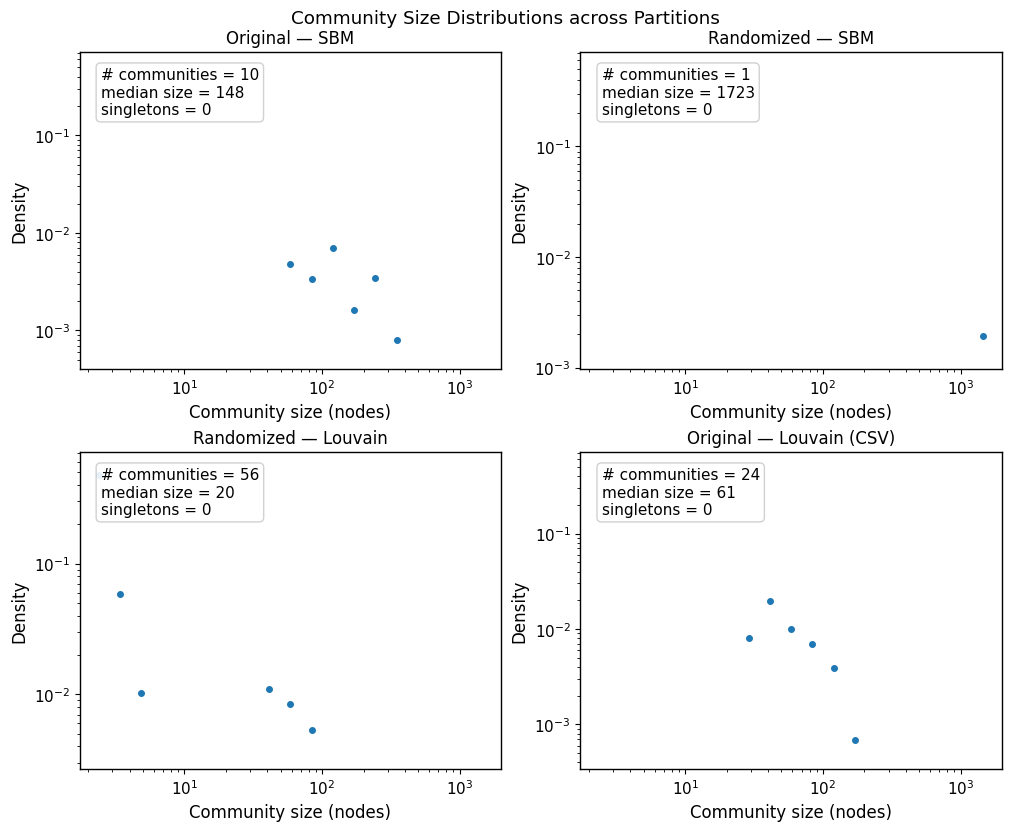

In [22]:
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from pathlib import Path

def P(p): 
    return Path(p).expanduser().resolve()
    
files = {
    "Original — SBM":               P("./partition.json"),
    "Randomized — SBM":             P("./partition_randomized_SBM.json"),
    "Randomized — Louvain":         P("./partition_randomized_Louvain.json"),
    "Original — Louvain (CSV)":     P("./partition_Louvain.json"),
}

# ==== 1) Load partitions ====
partitions = {}
for title, path in files.items():
    p = Path(path)
    if not p.exists():
        print(f"[warn] Missing: {path} — skipping this subplot.")
        continue
    with open(p, "r") as f:
        partitions[title] = json.load(f)  # {node_id(str): community_id(int)}

if len(partitions) == 0:
    raise RuntimeError("No partitions loaded. Check the file paths or pass dicts directly (Option B).")

# ==== 2) Convert {node->block} to size arrays ====
def community_sizes(partition_dict):
    # partition_dict: {node_label: block_id}
    counts = Counter(partition_dict.values())   # {block_id: size}
    return np.array(sorted(counts.values()))    # ascending sizes

# gather sizes and also record stats to harmonize axes
all_sizes = {}
for name, part in partitions.items():
    sizes = community_sizes(part)
    all_sizes[name] = sizes

# ==== 3) Decide axes + bins consistently across subplots ====
# x-axis (community size) limits
all_min = min(s.min() for s in all_sizes.values())
all_max = max(s.max() for s in all_sizes.values())

# logarithmic binning for size distribution histogram
def log_bins(xmin, xmax, n=20):
    xmin = max(1, xmin)  # sizes are ≥1
    return np.logspace(math.log10(xmin), math.log10(xmax), n)

bins = log_bins(all_min, all_max, n=20)

# y-axis: plot probability density (normalized histogram) to compare fairly
# and set a common y-limit after we compute the max density across subplots.
ymax = 0.0

# Precompute histograms so we can set consistent y-limits
hists = {}
for name, sizes in all_sizes.items():
    # histogram of community sizes
    h, edges = np.histogram(sizes, bins=bins, density=True)
    hists[name] = (h, edges)
    if h.max() > ymax:
        ymax = h.max()

# ==== 4) Plot — 2x2 grid ====
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "figure.figsize": (10, 8),
    "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(2, 2, constrained_layout=True)
axes = axes.ravel()

titles = list(all_sizes.keys())
for ax, title in zip(axes, titles):
    sizes = all_sizes[title]
    h, edges = hists[title]

    # midpoints for line/marker plotting on log-x
    mids = np.sqrt(edges[:-1] * edges[1:])

    ax.plot(mids, h, marker='o', linestyle='', linewidth=1.5, markersize=4)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("Community size (nodes)")
    ax.set_ylabel("Density")
    ax.set_title(title)

    # annotate summary stats
    n_blocks = len(sizes)
    median = np.median(sizes)
    s1 = np.sum(sizes == 1)
    ax.text(0.05, 0.95,
            f"# communities = {n_blocks}\nmedian size = {int(median)}\nsingletons = {s1}",
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.9))

    # keep consistent y-limits across panels; avoid zero/underflow
    ax.set_ylim(max(1e-4, h[h>0].min()/2), ymax*1.5)

# If fewer than 4 partitions loaded, hide the extra axes
for i in range(len(titles), 4):
    fig.delaxes(axes[i])

# overall title (optional)
fig.suptitle("Community Size Distributions across Partitions", y=1.02)

# save high-res
out = "community_size_distributions.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print(f"Saved figure → {out}")
plt.show()


In [16]:
# --- Original SBM ---
state = gt.minimize_blockmodel_dl(g)  # or degree-corrected: state_args=dict(deg_corr=True)
blocks = state.get_blocks()
B = state.get_B()
print("[ORIG SBM] get_B():", B)
print("[ORIG SBM] unique blocks from property:", np.unique(blocks.a).size)
# size distribution
from collections import Counter
sizes_sbm = Counter(int(blocks[v]) for v in g.vertices())
print("[ORIG SBM] n communities (Counter keys):", len(sizes_sbm))
print("[ORIG SBM] top sizes:", sorted(sizes_sbm.values(), reverse=True)[:10])


[ORIG SBM] get_B(): 1723
[ORIG SBM] unique blocks from property: 7
[ORIG SBM] n communities (Counter keys): 7
[ORIG SBM] top sizes: [524, 310, 250, 195, 188, 162, 94]


In [17]:
sbm_state = gt.minimize_blockmodel_dl(g_rand)  # or state_args=dict(deg_corr=True)
sbm_blocks = sbm_state.get_blocks()
print("[RAND SBM] get_B():", sbm_state.get_B())
print("[RAND SBM] unique blocks:", np.unique(sbm_blocks.a).size)
sizes_rand_sbm = Counter(int(sbm_blocks[v]) for v in g_rand.vertices())
print("[RAND SBM] n communities:", len(sizes_rand_sbm))


[RAND SBM] get_B(): 1723
[RAND SBM] unique blocks: 1
[RAND SBM] n communities: 1


In [18]:
print("[RAND Louvain] n communities:", len(set(louvain_membership.values())))
print("[RAND Louvain] top community sizes:",
      sorted(Counter(louvain_membership.values()).values(), reverse=True)[:10])


[RAND Louvain] n communities: 56
[RAND Louvain] top community sizes: [90, 89, 82, 81, 80, 78, 76, 75, 72, 67]


In [19]:
def load_and_count(path):
    with open(path, "r") as f:
        p = json.load(f)  # {node_label: community_id}
    from collections import Counter
    sizes = Counter(p.values())
    print(f"[CHECK JSON] {path}: nodes={len(p)}, communities={len(sizes)}")
    return p, sizes

_ = load_and_count("partition.json")                      # Original — SBM
_ = load_and_count("partition_randomized_SBM.json")       # Randomized — SBM
_ = load_and_count("partition_randomized_Louvain.json")   # Randomized — Louvain
_ = load_and_count("partition_Louvain.json")              # From CSV (Gephi)


[CHECK JSON] partition.json: nodes=1723, communities=10
[CHECK JSON] partition_randomized_SBM.json: nodes=1723, communities=1
[CHECK JSON] partition_randomized_Louvain.json: nodes=1723, communities=56
[CHECK JSON] partition_Louvain.json: nodes=1723, communities=24
